In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda


In [2]:
data = torch.load("../../src/data/bidding_tensors.pt", weights_only=True)

dataset = TensorDataset(data)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_dim = data.shape[1]
print(f"Total de amostras: {len(dataset)}")
print(f"Treino: {len(train_dataset)} | Teste: {len(test_dataset)}")

Total de amostras: 6152
Treino: 4921 | Teste: 1231


In [3]:
class AnomalyAutoEncoder(nn.Module):
    def __init__(self, input_dim: int):
        super(AnomalyAutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

model = AnomalyAutoEncoder(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [4]:
epochs = 100
history_train_loss = []
history_val_loss = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        reconstructed = model(x)
        loss = criterion(reconstructed, x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[0].to(device)
            reconstructed = model(x)
            loss = criterion(reconstructed, x)
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)
    history_train_loss.append(avg_train)
    history_val_loss.append(avg_val)

print("Treinamento concluído!")

Treinamento concluído!


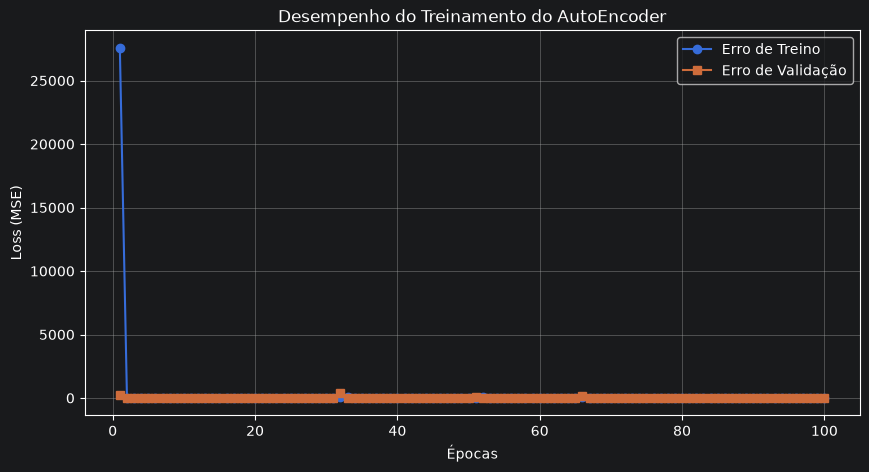

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_train_loss, label='Erro de Treino', marker='o')
plt.plot(range(1, epochs + 1), history_val_loss, label='Erro de Validação', marker='s')
plt.title('Desempenho do Treinamento do AutoEncoder')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
model.eval()
with torch.no_grad():
    all_test_data = test_dataset[:][0].to(device)
    reconstructions = model(all_test_data)
    errors = torch.mean((all_test_data - reconstructions) ** 2, dim=1).cpu().numpy()

threshold = np.percentile(errors, 95)
anomalies = errors > threshold
total_anomalies = np.sum(anomalies)

print(f"Limiar Dinâmico (Percentil 95): {threshold:.6f}")
print(f"Total de anomalias encontradas: {total_anomalies} de {len(all_test_data)}")

Limiar Dinâmico (Percentil 95): 0.004704
Total de anomalias encontradas: 56 de 1231


Um histograma ajuda a visualizar a linha de corte. A grande maioria dos dados terá erro próximo a zero, enquanto as anomalias ficarão na cauda direita.

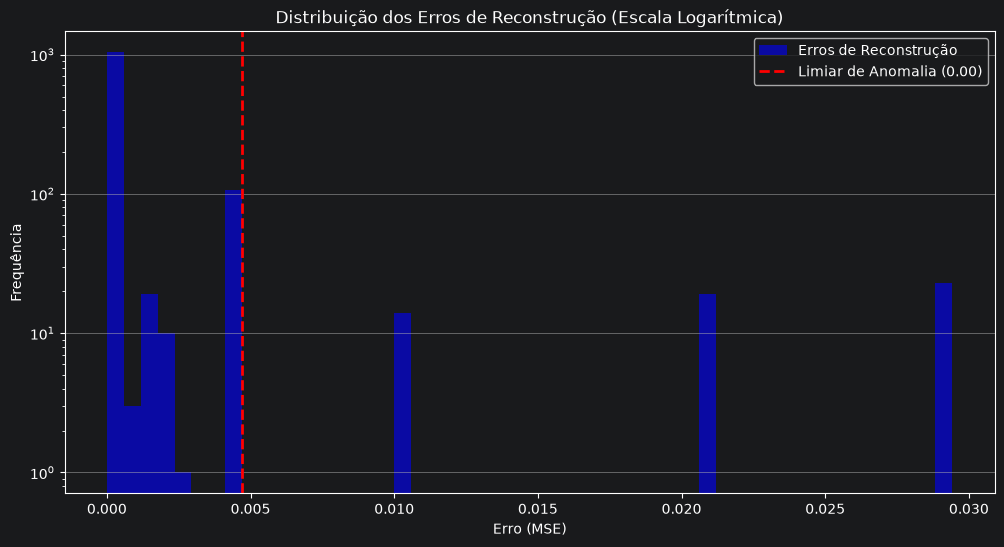

In [7]:
plt.figure(figsize=(12, 6))

plt.hist(errors, bins=50, color='blue', alpha=0.6, label='Erros de Reconstrução')
plt.axvline(x=threshold, color='red', linestyle='dashed', linewidth=2, label=f'Limiar de Anomalia ({threshold:.2f})')

plt.yscale('log')
plt.title('Distribuição dos Erros de Reconstrução (Escala Logarítmica)')
plt.xlabel('Erro (MSE)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()